# 03 -- Feature Engineering

**Goal:** turn `master_clean.csv` (the output of `02_Exploratory_Data_Analysis.ipynb`)
into a modelling-ready dataset -- add real engineered features from race
history, split it into train/test the same time-based way every other
notebook in this project does, and save both pieces so
`04_model.ipynb` can load them directly.

**What's new here that notebook 02 didn't already give us:** rolling
driver and constructor *form* -- how well a driver/team has been doing
over their last 5 races, computed so that a race never sees its own
result or any future race. Notebook 02's 8 features (grid position,
qualifying time, weather) describe *this one race*. These new features
describe *momentum going into it* -- a different kind of information the
model has never had access to before.


In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


---
## Section 1 -- Configuration

Same pattern as every other notebook in this project -- paths and column
lists defined once here, referenced everywhere below.


In [2]:
PATHS = {
    'input': '../data/processed/master_clean.csv',
    'train_output': '../data/processed/train.csv',
    'test_output': '../data/processed/test.csv',
    'config_output': '../data/processed/feature_config.json',
    'plots': '../data/figures/',
}

TARGET = 'points_finish'

# From 02_Exploratory_Data_Analysis.ipynb, Section 12 -- the 8 pre-race
# features that survived the multicollinearity cleanup.
BASE_NUMERIC_FEATURES = [
    'grid_position', 'best_qual_time_s', 'air_temp_max', 'track_temp_min',
    'wind_speed_mean', 'winddirection_mean', 'track_temp_range', 'season_progress',
]
CATEGORICAL_FEATURES = ['country_code']


---
## Section 2 -- Load Data

Loads the cleaned dataset notebook 02 saved -- no re-cleaning here, that
work is already done.


In [3]:
df = pd.read_csv(PATHS['input'])
df['date'] = pd.to_datetime(df['date'])

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Shape: 1,838 rows x 55 columns


---
## Section 2B -- Check Previously-Unused Pre-Race Columns

Before building anything brand new, worth checking something simpler first:
notebook 02 already collected and cleaned several pre-race columns that never
made it into `BASE_NUMERIC_FEATURES` -- `qual_position`, `air_temp_mean`,
`air_temp_min`, `track_temp_mean`, `track_temp_max`, `wind_speed_max`. They're
sitting right there in `master_clean.csv`, already safe (known before lights
out), just never checked against the target.

There are two different ways a column like this can turn out to be dead
weight: it barely moves with the target at all (the way
`circuit_points_finish_rate` did in Section 6B), or it's really just a
duplicate of a feature already in the model wearing a different name --
`qual_position` is a good candidate for that, since grid order comes straight
from qualifying results, so it's probably just `grid_position` again. Checking
both before deciding whether to add anything.

In [4]:
candidate_columns = [
    'qual_position', 'air_temp_mean', 'air_temp_min',
    'track_temp_mean', 'track_temp_max', 'wind_speed_max',
]

print("Correlation with points_finish (the target):")
print(df[candidate_columns].corrwith(df[TARGET].astype(float)).sort_values(key=abs, ascending=False).round(3))

print("\nCorrelation with features already in BASE_NUMERIC_FEATURES (checking for duplicates):")
print(df[candidate_columns + BASE_NUMERIC_FEATURES].corr().loc[candidate_columns, BASE_NUMERIC_FEATURES].round(2))

Correlation with points_finish (the target):
qual_position     -0.596
track_temp_mean    0.001
track_temp_max     0.001
wind_speed_max    -0.001
air_temp_mean      0.000
air_temp_min       0.000
dtype: float64

Correlation with features already in BASE_NUMERIC_FEATURES (checking for duplicates):
                 grid_position  best_qual_time_s  air_temp_max  \
qual_position             0.93              0.09          0.00   
air_temp_mean             0.00             -0.04          0.99   
air_temp_min              0.00             -0.03          0.98   
track_temp_mean           0.00             -0.21          0.72   
track_temp_max            0.00             -0.20          0.68   
wind_speed_max           -0.01              0.03          0.00   

                 track_temp_min  wind_speed_mean  winddirection_mean  \
qual_position             -0.00            -0.00                0.00   
air_temp_mean              0.76             0.03               -0.14   
air_temp_min            

### Decision: none of these six columns get added

`qual_position` correlates strongly with the target (-0.596) -- but also
correlates 0.93 with `grid_position`, already in the model. That's exactly
what was expected: grid order comes directly from qualifying results, so this
is the same information under a different name, not a second opinion worth
adding.

The other five -- `air_temp_mean`, `air_temp_min`, `track_temp_mean`,
`track_temp_max`, `wind_speed_max` -- all came back essentially flat
(correlation between 0.000 and 0.001 with `points_finish`). Makes sense in
hindsight: weather conditions make a race harder or easier for *everyone*
roughly equally, they don't pick out who specifically finishes where -- and
the model already has `air_temp_max`, `track_temp_min`, `track_temp_range`,
and `wind_speed_mean` covering the weather angle. `BASE_NUMERIC_FEATURES`
stays exactly as it was -- a useful result even though nothing got added:
now it's a checked fact instead of an assumption.

---
## Section 3 -- Engineer Rolling Form Features

### Why "form" and not just season-long stats?

A driver's finishing position depends a lot on how they've been doing
*recently* -- a driver on a hot streak (good car, good confidence) is a
different bet than one who's been crashing out for a month, even if their
season-long average looks identical. "Last 5 races" captures that
recent-momentum signal without needing to know anything about who the
driver is by name.

### Why `.shift(1)` before `.rolling()`?

This is the one line in this whole notebook that matters most for
avoiding data leakage. `.rolling(5)` on its own, for the row for race N,
would include race N's *own* result in its own "recent form" average --
that's using the answer to predict the answer. `.shift(1)` moves every
value down by one race first, so race N's rolling average only ever sees
races 1 through N-1. The very first race a driver appears in has no prior
races at all, so it comes out `NaN` -- left as `NaN` on purpose (see the
missing-values note at the end of this section), not filled with a guess.

### Why sort by driver (or constructor) and date first?

`.rolling()` operates on rows in the order they appear *within each
group* -- it has no idea what a "date" is, it just looks at the last 5
rows. Sorting by `['driver_id', 'date']` first guarantees "last 5 rows for
this driver" and "last 5 *races* for this driver, in order" mean the same
thing.


In [5]:
# Sort chronologically per driver -- required for rolling() to mean
# "the last 5 races", not just "5 arbitrary rows".
df = df.sort_values(['driver_id', 'date'])

df['driver_form_points_last5'] = (
    df.groupby('driver_id')['points']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

df['driver_points_finish_rate_last5'] = (
    df.groupby('driver_id')['points_finish']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# ~s flips True/False (finished/DNF) so the rolling mean of "not finished"
# reads directly as a DNF rate -- 0.4 means "DNF'd 40% of their last 5 races".
df['driver_dnf_rate_last5'] = (
    df.groupby('driver_id')['finished']
    .transform(lambda s: (~s).shift(1).rolling(5, min_periods=1).mean())
)


### Two more driver-level features, same trick (plus one new idea)

- `driver_grid_position_last5` -- the exact same `.shift(1)` +
  `.rolling(5)` pattern as above, just applied to `grid_position` instead
  of `points`. Is this driver's *qualifying* pace trending better or worse
  lately, separate from wherever they happen to start today?

- `driver_teammate_gap_last5` -- teammates share the same car, so the
  *difference* between a driver's points and their teammate's points in
  the same race isolates driver skill from car quality. This needs one
  extra step first: working out how many points the teammate scored.
  Almost every constructor fields exactly 2 drivers per race (checked
  against the real data: 918 of 920 constructor-races) -- so "teammate's
  points" is just "the team's combined points that race, minus this
  driver's own points," no fancier lookup needed. The 2 races with only 1
  driver get a `NaN` gap -- same honest handling as every other
  missing-history case in this notebook.


In [6]:
df['driver_grid_position_last5'] = (
    df.groupby('driver_id')['grid_position']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# Teammate's points = the team's combined points that race, minus this
# driver's own points -- works cleanly because almost every team fields
# exactly 2 drivers per race.
team_points_total = df.groupby(['year', 'round', 'constructor_id'])['points'].transform('sum')
team_driver_count = df.groupby(['year', 'round', 'constructor_id'])['driver_id'].transform('nunique')

df['teammate_points'] = np.where(team_driver_count == 2, team_points_total - df['points'], np.nan)

# Positive = this driver outscored their teammate in that race.
df['points_gap_vs_teammate'] = df['points'] - df['teammate_points']

df['driver_teammate_gap_last5'] = (
    df.groupby('driver_id')['points_gap_vs_teammate']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

df['driver_season_avg_points_so_far'] = (
    df.groupby(['driver_id', 'year'])['points']
    .transform(lambda s: s.shift(1).expanding().mean())
)

# Drop the two intermediate columns -- only the rolling result is a real
# feature, the per-race gap itself was just a stepping stone to get there.
df = df.drop(columns=['teammate_points', 'points_gap_vs_teammate'])


### Three more rolling features: race-day performance history

- `driver_positions_gained_last5` -- same `.shift(1)` + `.rolling(5)` pattern
  as everything above, applied to `positions_gained` (`grid_position -
  finish_position`, already computed in notebook 02). Grid position and
  finish position are the same kind of unit at every circuit -- "how many
  places" -- so this one's safe to roll as-is: is this driver's race-craft
  (overtaking, defending) trending up or down lately?

- `driver_pace_ratio_last5` and `driver_consistency_last5` need one extra
  step first: **raw lap times can't be compared across circuits without
  normalising within the race first.** A Monaco lap (~74s) and a Spa lap
  (~106s) are just different units -- rolling `avg_lap_time` directly would
  mix them together meaninglessly. The fix is to make every race's lap
  time *relative to that race* before rolling anything:
  - `race_pace_ratio` = this driver's average lap time / the whole field's
    median lap time, *in that one race*. 1.02 means "2% slower than the
    field's midpoint that day" -- a number that means the same thing at
    Monaco or at Spa.
  - `lap_time_cv` (coefficient of variation) = `std_lap_time /
    avg_lap_time`. A longer track has bigger absolute lap times *and*
    bigger absolute swings between laps, but dividing one by the other
    cancels that out, so this is comparable across circuits the same way.

  Both get rolled into a last-5 average the usual way, using `.shift(1)` so
  a race never sees its own lap times.


In [7]:
# positions_gained is already in consistent units (places) everywhere --
# no normalisation needed the way lap times do.
df['driver_positions_gained_last5'] = (
    df.groupby('driver_id')['positions_gained']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# Race-relative pace, computed BEFORE rolling -- see markdown above for why
# raw avg_lap_time can't be rolled directly across different circuits.
race_median_lap_time = df.groupby(['year', 'round'])['avg_lap_time'].transform('median')
df['race_pace_ratio'] = df['avg_lap_time'] / race_median_lap_time

df['driver_pace_ratio_last5'] = (
    df.groupby('driver_id')['race_pace_ratio']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# Coefficient of variation -- same cross-circuit comparability trick as
# race_pace_ratio, applied to lap-time consistency instead of raw pace.
df['lap_time_cv'] = df['std_lap_time'] / df['avg_lap_time']

df['driver_consistency_last5'] = (
    df.groupby('driver_id')['lap_time_cv']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

### Two more constructor-level features, same trick

- `constructor_dnf_rate_last5` -- same rolling-DNF-rate idea as
  `driver_dnf_rate_last5`, just grouped by team instead of driver.
  Isolates car/team reliability from driver-caused DNFs (a crash is on
  the driver; an engine failure is on the car).
- `constructor_avg_pit_duration_last5` -- rolling average pit stop
  duration for the team. `avg_pit_duration` is a post-race column (only
  known *after* a race finishes) -- getting the exact same `.shift(1)`
  treatment as everything else is the proof this trick isn't limited to
  `points`, it generalises to any historical column.


In [8]:
# Constructor form needs its own chronological sort -- the driver-sorted
# order above interleaves every driver who's ever raced for a team, which
# is not the same thing as that team's own race-by-race order.
df = df.sort_values(['constructor_id', 'date'])

df['constructor_form_points_last5'] = (
    df.groupby('constructor_id')['points']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

df['constructor_dnf_rate_last5'] = (
    df.groupby('constructor_id')['finished']
    .transform(lambda s: (~s).shift(1).rolling(5, min_periods=1).mean())
)

df['constructor_avg_pit_duration_last5'] = (
    df.groupby('constructor_id')['avg_pit_duration']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

# Same trick again, this time on how many stops the team tends to make --
# some teams run more aggressive multi-stop strategies than others.
df['constructor_pit_stops_last5'] = (
    df.groupby('constructor_id')['total_pit_stops']
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)

ROLLING_FEATURES = [
    'driver_form_points_last5', 'driver_points_finish_rate_last5',
    'driver_dnf_rate_last5', 'driver_grid_position_last5',
    'driver_teammate_gap_last5', 'driver_season_avg_points_so_far',
    'driver_positions_gained_last5', 'driver_pace_ratio_last5',
    'driver_consistency_last5',
    'constructor_form_points_last5', 'constructor_dnf_rate_last5',
    'constructor_avg_pit_duration_last5', 'constructor_pit_stops_last5',
]

# Back to a stable, readable row order for everything below.
df = df.sort_values(['year', 'round', 'driver_id']).reset_index(drop=True)

### Making it concrete: one driver's rolling form

Verstappen's `driver_form_points_last5` through the start of a season --
each row is one race, and the rolling column shows what the *previous* up
to 5 races looked like at that point. The first race of the dataset for
any driver is always `NaN` -- there's no history yet to average.


In [9]:
example = (
    df[df['driver_id'] == 'max_verstappen']
    .sort_values('date')
    [['date', 'points', 'driver_form_points_last5']]
    .head(8)
)
print(example.to_string(index=False))


      date  points  driver_form_points_last5
2022-03-20     0.0                       NaN
2022-03-27    25.0                  0.000000
2022-04-10     0.0                 12.500000
2022-04-24    26.0                  8.333333
2022-05-08    26.0                 12.750000
2022-05-22    25.0                 15.400000
2022-05-29    15.0                 20.400000
2022-06-12    25.0                 18.400000


---
## Section 4 -- Sanity-Check the New Features

Before trusting these features enough to model with them, check they
actually move together with the target -- the same correlation check
notebook 02's Section 11 used for the original 8 features, just applied
to the 8 new ones. This isn't a full repeat of notebook 02's
multicollinearity analysis (these are a genuinely different *kind* of
feature -- recent history, not race-day conditions -- so they're not
expected to duplicate the existing ones), just confirmation they're worth
keeping.


Correlation with points_finish:
driver_grid_position_last5           -0.546
driver_season_avg_points_so_far       0.520
driver_form_points_last5              0.508
driver_points_finish_rate_last5       0.500
constructor_form_points_last5         0.479
driver_pace_ratio_last5              -0.457
driver_dnf_rate_last5                -0.422
constructor_dnf_rate_last5           -0.401
driver_teammate_gap_last5             0.129
constructor_avg_pit_duration_last5   -0.103
driver_positions_gained_last5        -0.096
driver_consistency_last5             -0.027
constructor_pit_stops_last5           0.004
dtype: float64


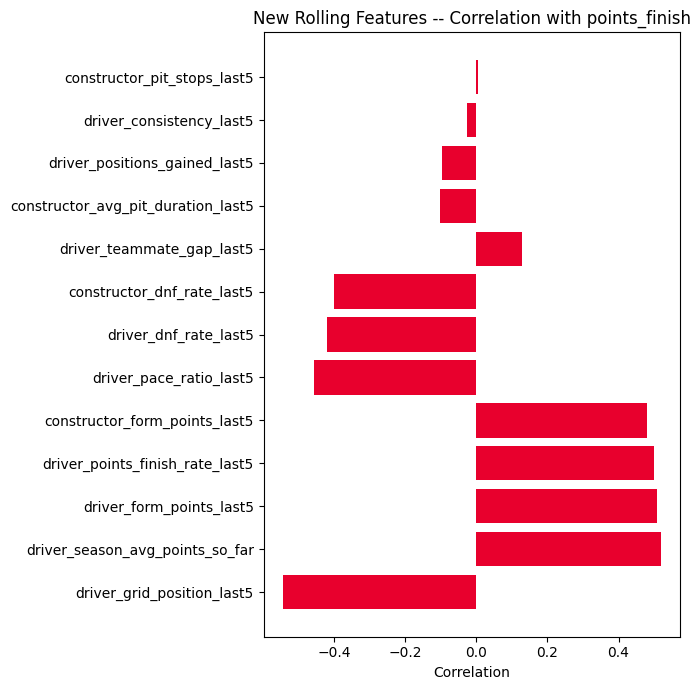

In [10]:
correlations = (
    df[ROLLING_FEATURES]
    .corrwith(df[TARGET].astype(float))
    .sort_values(key=abs, ascending=False)
)
print("Correlation with points_finish:")
print(correlations.round(3))

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(correlations.index, correlations.values, color='#e8002d')
ax.set_title('New Rolling Features -- Correlation with points_finish')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}feature_01_rolling_correlation.png", dpi=130, bbox_inches='tight')
plt.show()

### Decision: keep pace ratio and positions gained, drop consistency and pit stops

Two clear keepers: `driver_pace_ratio_last5` came back at -0.457 -- one of
the strongest features in the whole set, right up with
`driver_grid_position_last5` and `driver_season_avg_points_so_far`. Makes
sense -- how fast a driver's actually been going lately is about as direct a
signal as it gets. `driver_positions_gained_last5` is weaker (-0.096), but
that's still in the same range as `constructor_avg_pit_duration_last5`
(-0.103) and `driver_teammate_gap_last5` (0.129), both already kept -- and
it's measuring something genuinely different (race-craft, not raw pace) from
anything else in the set, so it stays too.

Two drops: `driver_consistency_last5` (-0.027) and
`constructor_pit_stops_last5` (0.004) both came back essentially flat -- the
same "no real signal" territory `circuit_points_finish_rate` landed in back
in Section 6B. Both have a believable reason why: lap-time swings within a
race are driven mostly by things outside a driver's control (safety cars,
traffic, changing track conditions), and how many times a team pits is
driven mostly by that specific circuit's tyre strategy, not a stable team
trait -- so rolling either one by driver/team mostly rolls up noise. Dropped
from `ROLLING_FEATURES` below; the columns themselves stay in `df` in case
they're useful for a different question later.

In [11]:
ROLLING_FEATURES = [
    f for f in ROLLING_FEATURES
    if f not in ('driver_consistency_last5', 'constructor_pit_stops_last5')
]
print(f"Rolling features kept: {len(ROLLING_FEATURES)}")
print(ROLLING_FEATURES)

Rolling features kept: 11
['driver_form_points_last5', 'driver_points_finish_rate_last5', 'driver_dnf_rate_last5', 'driver_grid_position_last5', 'driver_teammate_gap_last5', 'driver_season_avg_points_so_far', 'driver_positions_gained_last5', 'driver_pace_ratio_last5', 'constructor_form_points_last5', 'constructor_dnf_rate_last5', 'constructor_avg_pit_duration_last5']


---
## Section 4B -- Championship Standings Features

All the rolling features so far describe *recent form* -- the last 5 races.
This one is a different kind of signal: **where does this driver/team sit in
the championship right now**, using every race so far this season, not just
the last 5. A driver clinging to 2nd place in the standings with 3 races left
might drive differently (more conservative, protecting the position) than one
mid-table with nothing left to lose -- and a team fighting for a
constructors' title tends to prioritise upgrades differently than one that's
already out of contention. `driver_season_avg_points_so_far` (built in
Section 3) captures part of this, but an *average* doesn't say anything about
rank -- 6th out of 20 and 6th out of 6 are very different situations with the
same average.

Same `.shift(1)` safety rule as everywhere else: a driver's standing *before*
this race can only use points scored in races before it, never this one.

In [12]:
# Cumulative points BEFORE this race, reset every season (a driver's 2023
# standing has nothing to do with their 2022 points total). Unlike the
# rolling features, 0 points at the start of a season isn't missing data --
# it's a real fact -- so this gets filled with 0, not left as NaN.
df = df.sort_values(['driver_id', 'date'])

df['driver_cum_points_before_race'] = (
    df.groupby(['driver_id', 'year'])['points']
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0)
)

# Rank every driver's cumulative points within each individual race --
# rank 1 = championship leader going into that race.
df['driver_standing_before_race'] = (
    df.groupby(['year', 'round'])['driver_cum_points_before_race']
    .rank(method='min', ascending=False)
)

# Constructors first need their OWN cumulative points -- both drivers'
# points combined -- computed on one row per team per race so a team with
# 2 drivers doesn't get double-counted in the running total.
constructor_race_totals = (
    df.groupby(['year', 'round', 'constructor_id'])['points']
    .sum()
    .reset_index()
    .sort_values(['constructor_id', 'year', 'round'])
)
constructor_race_totals['constructor_cum_points_before_race'] = (
    constructor_race_totals.groupby(['constructor_id', 'year'])['points']
    .transform(lambda s: s.shift(1).expanding().sum())
    .fillna(0)
)

df = df.merge(
    constructor_race_totals[['year', 'round', 'constructor_id', 'constructor_cum_points_before_race']],
    on=['year', 'round', 'constructor_id'],
    how='left',
)

df['constructor_standing_before_race'] = (
    df.groupby(['year', 'round'])['constructor_cum_points_before_race']
    .rank(method='min', ascending=False)
)

df = df.sort_values(['year', 'round', 'driver_id']).reset_index(drop=True)

STANDINGS_FEATURES = ['driver_standing_before_race', 'constructor_standing_before_race']
df[STANDINGS_FEATURES].describe()

,driver_standing_before_race,constructor_standing_before_race
count,1838.000000,1838.000000
mean,9.730141,9.475517
std,5.636713,5.790782
min,1.000000,1.000000
25%,5.000000,5.000000
50%,10.000000,9.000000
75%,14.000000,15.000000
max,20.000000,19.000000


### Checking these against the target -- and against what we already have

Same question as every other new feature in this notebook: does it actually
move with `points_finish`, and is it just repeating a feature we already
built? `driver_standing_before_race` should correlate *negatively* --
standing 1 (the leader) should mean a *higher* chance of a points finish, so
a bigger standing number (further back in the pack) should mean a lower
chance. Also checking both against their closest cousins already in
`ROLLING_FEATURES`: `driver_season_avg_points_so_far` (same "season so far"
idea, no rank) and `constructor_form_points_last5` (same "how good is this
team" idea, but last-5 instead of season-to-date).

In [13]:
print("Correlation with points_finish:")
print(
    df[STANDINGS_FEATURES]
    .corrwith(df[TARGET].astype(float))
    .round(3)
)

print("\nRedundancy check against related features already built:")
print(
    df[STANDINGS_FEATURES + ['driver_season_avg_points_so_far', 'constructor_form_points_last5']]
    .corr()
    .round(2)
)

Correlation with points_finish:
driver_standing_before_race        -0.502
constructor_standing_before_race   -0.483
dtype: float64

Redundancy check against related features already built:
                                  driver_standing_before_race  \
driver_standing_before_race                              1.00   
constructor_standing_before_race                         0.89   
driver_season_avg_points_so_far                         -0.88   
constructor_form_points_last5                           -0.71   

                                  constructor_standing_before_race  \
driver_standing_before_race                                   0.89   
constructor_standing_before_race                              1.00   
driver_season_avg_points_so_far                              -0.83   
constructor_form_points_last5                                -0.78   

                                  driver_season_avg_points_so_far  \
driver_standing_before_race                                 -0.88

### Decision: keep both, but flag the multicollinearity for later

Both standings features carry real, strong signal --
`driver_standing_before_race` at -0.502 and `constructor_standing_before_race`
at -0.483, right in the same top tier as `driver_grid_position_last5` and
`driver_season_avg_points_so_far`. Exactly the direction expected: a bigger
standing number (further back in the championship) means a lower chance of a
points finish.

The redundancy numbers are the highest seen in this notebook, though --
`driver_standing_before_race` vs `driver_season_avg_points_so_far` at
r=-0.88, and vs `constructor_standing_before_race` at r=0.89. Following the
same call made for the driver/constructor form overlap (Section 3) and the
circuit/constructor encoding overlap (Section 6B) -- keep both in and let
`04_model.ipynb`'s feature-importance step show which ones the model
actually leans on, rather than guessing here. But this is a stronger overlap
than either of those two prior cases, so worth watching for the same kind of
effect already found once (F1 dipping slightly even as ROC-AUC rose,
because two correlated features were splitting credit for the same signal)
-- if that shows up again in `04_model.ipynb`, these standings features are
the first place to look.


In [14]:
ROLLING_FEATURES = ROLLING_FEATURES + STANDINGS_FEATURES
print(f"Rolling features (including standings): {len(ROLLING_FEATURES)}")
print(ROLLING_FEATURES)

Rolling features (including standings): 13
['driver_form_points_last5', 'driver_points_finish_rate_last5', 'driver_dnf_rate_last5', 'driver_grid_position_last5', 'driver_teammate_gap_last5', 'driver_season_avg_points_so_far', 'driver_positions_gained_last5', 'driver_pace_ratio_last5', 'constructor_form_points_last5', 'constructor_dnf_rate_last5', 'constructor_avg_pit_duration_last5', 'driver_standing_before_race', 'constructor_standing_before_race']


---
## Section 5 -- Missing Values

Every rolling feature is `NaN` for a driver's or constructor's first
appearance in the dataset (no history yet) -- expect a small, known,
honest amount of missing data, not a bug. Left unfilled here on purpose:
`04_model.ipynb`'s preprocessing pipeline already imputes every numeric
column with the training-set median, exactly the same way it already
handles `winddirection_mean` and the other partially-missing weather
columns today -- one imputation strategy, applied consistently, rather
than a special case for these eight.


In [15]:
ALL_NUMERIC_FEATURES = BASE_NUMERIC_FEATURES + ROLLING_FEATURES
ALL_FEATURES = ALL_NUMERIC_FEATURES + CATEGORICAL_FEATURES

print("Missing values in modelling columns:")
print(df[ALL_FEATURES + [TARGET]].isna().mean().mul(100).round(1).sort_values(ascending=False))


Missing values in modelling columns:
country_code                          51.1
winddirection_mean                    29.4
driver_season_avg_points_so_far        4.8
driver_form_points_last5               1.7
driver_dnf_rate_last5                  1.7
driver_grid_position_last5             1.7
driver_teammate_gap_last5              1.7
driver_pace_ratio_last5                1.7
driver_points_finish_rate_last5        1.7
driver_positions_gained_last5          1.7
track_temp_min                         1.1
air_temp_max                           1.1
wind_speed_mean                        1.1
track_temp_range                       1.1
best_qual_time_s                       1.0
constructor_dnf_rate_last5             0.7
constructor_avg_pit_duration_last5     0.7
constructor_form_points_last5          0.7
grid_position                          0.0
season_progress                        0.0
driver_standing_before_race            0.0
constructor_standing_before_race       0.0
points_finish    

---
## Section 6 -- Train/Test Split

Same time-based split every notebook in this project uses, and for the
same reason: rows aren't independent (~20 share each race's conditions),
and a random split would leak information across the boundary and let the
model "see the future" relative to some of its own test rows. Train on
2022-2024, test on 2025 -- the most recent complete-ish season.

This split has to happen in *this* notebook, not `04_model.ipynb`,
because it's the boundary that will define "training data" for whatever
imputer/scaler gets fit next -- deciding it here keeps that decision in
one place instead of two.


In [16]:
train_df = df[df['year'] < 2025].copy()
test_df = df[df['year'] == 2025].copy()

print(f"Train: {train_df.shape[0]:,} rows ({sorted(train_df['year'].unique())})")
print(f"Test:  {test_df.shape[0]:,} rows ({sorted(test_df['year'].unique())})")


Train: 1,359 rows ([np.int64(2022), np.int64(2023), np.int64(2024)])
Test:  479 rows ([np.int64(2025)])


---
## Section 6B -- Target-Encode Circuit and Constructor

**Why this has to happen here, not back in Section 3:** target encoding replaces
a category (like `circuit_id`) with the *average target value* seen for that
category historically. If that average were computed across the whole dataset --
train and test together -- some of the test set's own future results would leak
into a number the model gets to see as an input before making its prediction.
So this has to be *fit* on `train_df` only, after the split already exists in
Section 6, then applied to both `train_df` and `test_df` using values learned
only from training data. It's the same "fit on train, apply to both" idea
`04_model.ipynb`'s imputer and scaler already use -- just done here instead,
since it needs to happen before the feature list gets saved.

**Unseen-category fallback:** if `test_df` ever contained a circuit or
constructor that never appeared in `train_df`, there'd be no learned average to
look up for it, and `.map()` would leave that row as `NaN`. The standard fix is
to fall back to the *overall* training-set average in that case --
`.fillna(global_mean)` below. Checked against the real data first: all 25
circuits and all 12 constructors in `test_df` (2025) already appear in
`train_df` (2022-2024), so the fallback isn't actually needed this time -- but
it's there so this notebook doesn't silently break if a new team debuts in a
future season.

In [17]:
# Circuit target encoding -- fit only on train_df, then applied to both.
circuit_lookup = train_df.groupby('circuit_id')[TARGET].mean()
circuit_global_mean = train_df[TARGET].mean()

train_df['circuit_points_finish_rate'] = train_df['circuit_id'].map(circuit_lookup)
test_df['circuit_points_finish_rate'] = test_df['circuit_id'].map(circuit_lookup).fillna(circuit_global_mean)

# Constructor target encoding -- same pattern.
constructor_lookup = train_df.groupby('constructor_id')[TARGET].mean()
constructor_global_mean = train_df[TARGET].mean()

train_df['constructor_points_finish_rate'] = train_df['constructor_id'].map(constructor_lookup)
test_df['constructor_points_finish_rate'] = test_df['constructor_id'].map(constructor_lookup).fillna(constructor_global_mean)

print("Circuit points-finish rate (train):")
print(circuit_lookup.sort_values().round(3))
print()
print("Constructor points-finish rate (train):")
print(constructor_lookup.sort_values().round(3))

Circuit points-finish rate (train):
circuit_id
americas         0.500
bahrain          0.500
baku             0.500
catalunya        0.500
imola            0.500
hungaroring      0.500
interlagos       0.500
jeddah           0.500
monaco           0.500
losail           0.500
marina_bay       0.500
miami            0.500
red_bull_ring    0.500
monza            0.500
ricard           0.500
rodriguez        0.500
zandvoort        0.500
shanghai         0.500
silverstone      0.500
spa              0.500
suzuka           0.500
vegas            0.500
villeneuve       0.500
yas_marina       0.500
albert_park      0.508
Name: points_finish, dtype: float64

Constructor points-finish rate (train):
constructor_id
sauber          0.021
williams        0.141
alphatauri      0.205
haas            0.206
alfa            0.216
rb              0.292
alpine          0.493
aston_martin    0.507
mclaren         0.713
ferrari         0.816
mercedes        0.868
red_bull        0.875
Name: points_finish, d

### Checking these against the target -- and against each other

Same correlation check as Section 4, just for these 2 new features, plus one
extra check worth doing in advance: `constructor_points_finish_rate` and
`constructor_form_points_last5` are both, in different ways, "how good is this
team" -- there's a real chance they tell the model almost the same thing
twice, the way `driver_form_points_last5` and `constructor_form_points_last5`
already turned out to overlap (Section 3, r=0.86).


In [18]:
print("Correlation with points_finish (train only):")
print(
    train_df[['circuit_points_finish_rate', 'constructor_points_finish_rate']]
    .corrwith(train_df[TARGET].astype(float))
    .round(3)
)
print()
print("Redundancy check -- constructor encoding vs. constructor_form_points_last5:")
print(
    train_df[['constructor_points_finish_rate', 'constructor_form_points_last5']]
    .corr()
    .round(3)
)
print()
print("Missing values after encoding (should be 0 both sides):")
print("train:", train_df[['circuit_points_finish_rate', 'constructor_points_finish_rate']].isna().sum().to_dict())
print("test: ", test_df[['circuit_points_finish_rate', 'constructor_points_finish_rate']].isna().sum().to_dict())

Correlation with points_finish (train only):
circuit_points_finish_rate        0.003
constructor_points_finish_rate    0.580
dtype: float64

Redundancy check -- constructor encoding vs. constructor_form_points_last5:
                                constructor_points_finish_rate  \
constructor_points_finish_rate                           1.000   
constructor_form_points_last5                            0.791   

                                constructor_form_points_last5  
constructor_points_finish_rate                          0.791  
constructor_form_points_last5                           1.000  

Missing values after encoding (should be 0 both sides):
train: {'circuit_points_finish_rate': 0, 'constructor_points_finish_rate': 0}
test:  {'circuit_points_finish_rate': 0, 'constructor_points_finish_rate': 0}


### Decision: drop `circuit_points_finish_rate`, keep `constructor_points_finish_rate`

`circuit_points_finish_rate` came back essentially flat -- every circuit at
0.500, one at 0.508, correlation 0.003 with the target. That's not a fluke,
it makes sense once you think about what `points_finish` actually measures:
"finished in the top 10 of ~20 starters" is roughly half the field at *every*
circuit, almost by definition -- a street circuit doesn't change how many cars
finish in the top half, only *which* ones. So this feature is dropped from
`ALL_NUMERIC_FEATURES` below -- the column stays in the saved data (in case
it's useful for a different question later), it's just not fed to the model.

`constructor_points_finish_rate` is kept despite the r=0.791 overlap with
`constructor_form_points_last5` -- same call made for the driver/constructor
form overlap earlier in this notebook (Section 3): worth keeping both in and
letting the model (and notebook 04's feature-importance step) show which one
it actually leans on, rather than guessing in advance which of two
correlated-but-not-identical features is more useful.


In [19]:
ALL_NUMERIC_FEATURES = ALL_NUMERIC_FEATURES + ['constructor_points_finish_rate']
ALL_FEATURES = ALL_NUMERIC_FEATURES + CATEGORICAL_FEATURES

print(f"Numeric features: {len(ALL_NUMERIC_FEATURES)}")
print(f"Total features:   {len(ALL_FEATURES)}")

Numeric features: 22
Total features:   23


---
## Section 7 -- Save Feature-Ready Data

Saves the full train/test dataframes (not just the modelling columns --
same reasoning as notebook 02's final save: identifiers and other columns
might matter for a different question later) plus a small
`feature_config.json` recording the target and feature lists.
`04_model.ipynb` reads its feature list from this file instead of
redefining it -- one source of truth, the same pattern already used for
`models/model_metadata.json`.


In [20]:
train_df.to_csv(PATHS['train_output'], index=False)
test_df.to_csv(PATHS['test_output'], index=False)

feature_config = {
    'target': TARGET,
    'numeric_features': ALL_NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'rolling_features': ROLLING_FEATURES,
}
with open(PATHS['config_output'], 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"Saved {train_df.shape[0]:,} train rows -> {PATHS['train_output']}")
print(f"Saved {test_df.shape[0]:,} test rows -> {PATHS['test_output']}")
print(f"Saved feature config -> {PATHS['config_output']}")


Saved 1,359 train rows -> ../data/processed/train.csv
Saved 479 test rows -> ../data/processed/test.csv
Saved feature config -> ../data/processed/feature_config.json


> **My notes on the rolling features:** _fill in once this runs -- do the
> correlation numbers in Section 4 surprise you? Does `driver_dnf_rate_last5`
> being negative make sense (higher recent DNF rate -> less likely to score
> points this time)? That's the kind of thing worth checking against your
> own F1 intuition before trusting a feature._
